In [247]:
import pandas as pd
import geopandas
import numpy

In [248]:
Alabama_places = geopandas.read_file(r"C:\Users\liamt\Documents\School Stuff\AES 408\Hw 2\cb_2024_01_place_500k\cb_2024_01_place_500k.shp")

In [249]:
Alabama_places

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,32704,02403782,1600000US0132704,0132704,Haleyville,Haleyville city,AL,Alabama,25,21713018,130983,"MULTIPOLYGON (((-87.60417 34.24614, -87.60201 ..."
1,01,45472,02406131,1600000US0145472,0145472,McIntosh,McIntosh town,AL,Alabama,43,2579767,0,"POLYGON ((-88.03726 31.27171, -88.03112 31.271..."
2,01,53784,02406982,1600000US0153784,0153784,Newbern,Newbern town,AL,Alabama,43,3010370,6872,"POLYGON ((-87.54125 32.60104, -87.52531 32.601..."
3,01,78204,02405634,1600000US0178204,0178204,Valley,Valley city,AL,Alabama,25,33384157,0,"MULTIPOLYGON (((-85.17006 32.7799, -85.17005 3..."
4,01,02836,02405172,1600000US0102836,0102836,Ashford,Ashford city,AL,Alabama,25,16064130,56699,"POLYGON ((-85.25721 31.17963, -85.25643 31.204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,01,63984,02407191,1600000US0163984,0163984,Reece City,Reece City town,AL,Alabama,43,9226254,0,"POLYGON ((-86.06752 34.04462, -86.0667 34.0452..."
590,01,29296,02406555,1600000US0129296,0129296,Gaylesville,Gaylesville town,AL,Alabama,43,3593015,94834,"POLYGON ((-85.58281 34.2614, -85.58111 34.2593..."
591,01,44536,02406051,1600000US0144536,0144536,Lowndesboro,Lowndesboro town,AL,Alabama,43,2050742,0,"POLYGON ((-86.62132 32.27615, -86.61304 32.276..."
592,01,55440,02407012,1600000US0155440,0155440,Notasulga,Notasulga town,AL,Alabama,43,36173002,398501,"POLYGON ((-85.7041 32.58211, -85.69565 32.5820..."


In [250]:
Alabama_places_reprojected = Alabama_places.to_crs("ESRI:102629")

<Axes: >

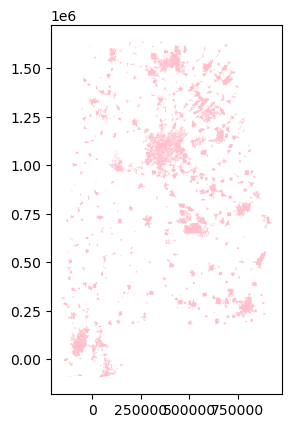

In [251]:
Alabama_places_reprojected.plot(color = "pink")

In [252]:
Coffee_Springs = Alabama_places_reprojected[Alabama_places_reprojected["NAME"]== "Coffee Springs"]

Coffee_Springs

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
383,01,16240,02406288,1600000US0116240,0116240,Coffee Springs,Coffee Springs town,AL,Alabama,43,2030176,29256,"POLYGON ((629458.063 242990.05, 629797.068 243..."


<Axes: >

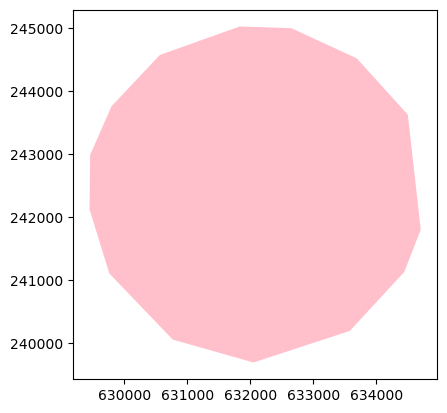

In [253]:
Coffee_Springs.plot(color = "pink")

In [254]:
Coffee_Springs_area = Coffee_Springs.area

Coffee_Springs_area

383    2.155013e+07
dtype: float64

In [255]:
Coffee_Springs_Radius = Coffee_Springs.minimum_bounding_radius()

print(Coffee_Springs_Radius)



383    2701.832296
dtype: float64


In [256]:
Coffee_Springs_calculated_radius = numpy.sqrt(Coffee_Springs_area/numpy.pi)
Coffee_Springs_calculated_radius

383    2619.087679
dtype: float64

In [257]:
Circle_factor_Coffee_Springs = Coffee_Springs_calculated_radius/Coffee_Springs_Radius

Circle_factor_Coffee_Springs

383    0.969375
dtype: float64

In [258]:
Birmingham = Alabama_places_reprojected[Alabama_places_reprojected["NAME"]== "Birmingham"]

Birmingham

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
173,01,07000,02403868,1600000US0107000,0107000,Birmingham,Birmingham city,AL,Alabama,25,380910502,6538593,"MULTIPOLYGON (((423398.975 1102085.737, 424206..."


<Axes: >

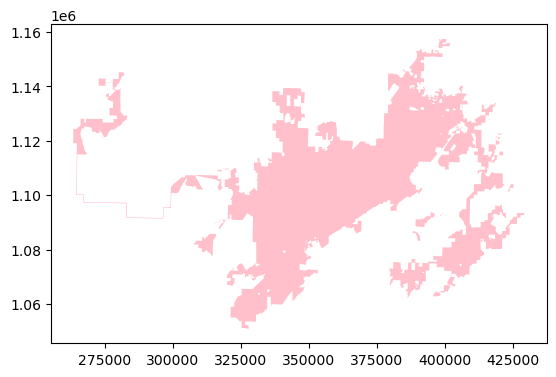

In [259]:
Birmingham.plot(color = "pink")


In [260]:
Birmingham_area = Birmingham.area
print(Birmingham_area)

Birmingham_Radius = Birmingham.minimum_bounding_radius()
print(Birmingham_Radius)

Birmingham_calculated_radius = numpy.sqrt(Birmingham_area/numpy.pi)
print(Birmingham_calculated_radius)

Circle_factor_Birmingham = Birmingham_calculated_radius/Birmingham_Radius
print(Circle_factor_Birmingham)

173    4.179205e+09
dtype: float64
173    84284.831137
dtype: float64
173    36473.036517
dtype: float64
173    0.432735
dtype: float64


In [261]:
Alabama_places_area = Alabama_places_reprojected.area

Alabama_places_radius = Alabama_places_reprojected.minimum_bounding_radius()

Alabama_places_calculated_radius = numpy.sqrt(Alabama_places_area/numpy.pi)

Circle_factor_Alabama_places = Alabama_places_calculated_radius/Alabama_places_radius
#print(Circle_factor_Alabama_places.sort_values(ascending = False))

Circle_factor_data = {"Circle_factor": Circle_factor_Alabama_places, "NAME": Alabama_places_reprojected["NAME"], "geometry": Alabama_places_reprojected["geometry"]}
Circle_factor_geodatabase = geopandas.GeoDataFrame(Circle_factor_data, geometry= "geometry")
print(Circle_factor_geodatabase.sort_values(by = "Circle_factor", ascending = False))

     Circle_factor                 NAME  \
386       0.986347             Brantley   
256       0.982975               Oakman   
289       0.977899            Goldville   
383       0.969375       Coffee Springs   
582       0.852113  Morrison Crossroads   
..             ...                  ...   
446       0.232829                Grant   
151       0.229816       South Vinemont   
200       0.209934                Hytop   
380       0.206757       Dauphin Island   
566       0.121988               Hayden   

                                              geometry  
386  POLYGON ((518928.934 394406.715, 519313.555 39...  
256  POLYGON ((177841.769 1173132.486, 178166.524 1...  
289  POLYGON ((668570.532 939760.721, 668800.575 94...  
383  POLYGON ((629458.063 242990.05, 629797.068 243...  
582  POLYGON ((754168.972 1063908.171, 754552.711 1...  
..                                                 ...  
446  POLYGON ((520706.298 1446503.419, 523196.965 1...  
151  MULTIPOLYGON (((346039

<Axes: >

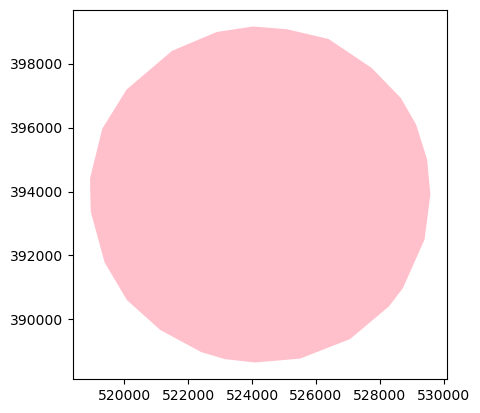

In [262]:
Brantley =Circle_factor_geodatabase[Circle_factor_geodatabase["NAME"] == "Brantley"]
Brantley.plot(color = "pink")

<Axes: >

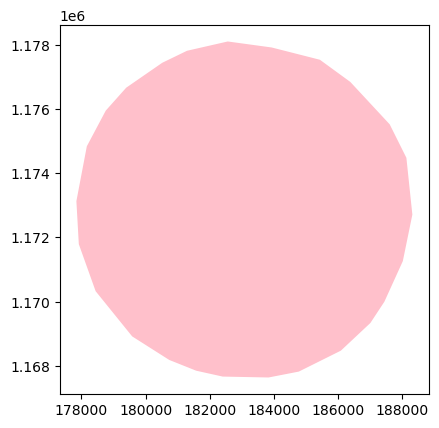

In [263]:
Oakman =Circle_factor_geodatabase[Circle_factor_geodatabase["NAME"] == "Oakman"]
Oakman.plot(color = "pink")

<Axes: >

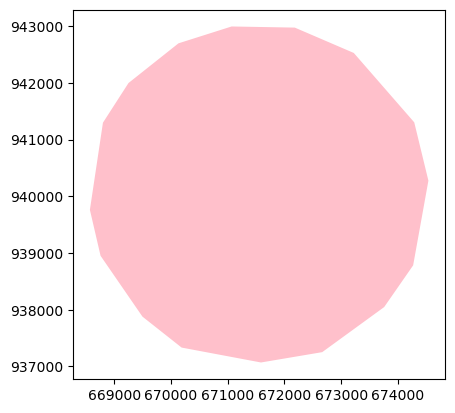

In [264]:
Goldville =Circle_factor_geodatabase[Circle_factor_geodatabase["NAME"] == "Goldville"]
Goldville.plot(color = "pink")

In [265]:
print("Final list of circular towns is: Brantley, Oakman, Goldville, and Coffee Springs")

#AI assistance from ChatGPT (Version GPT -4) and Google AI (Gemeni 3)
#AI was used to troubleshoot various errors as well as explaining how to create a GeoDataBase
#Google AI overview was also used to troubleshoot problems after googling certain questions to come up as needed

Final list of circular towns is: Brantley, Oakman, Goldville, and Coffee Springs
